# Inspección Inicial — HVFHS Diciembre 2024

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [6]:
dataset_dic = 'https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2024-12.parquet' #esta pagina lo maneja en parquet
dataset_zonas = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
df_zonas = pd.read_csv(dataset_zonas)
df = pd.read_parquet(dataset_dic) #para poder manerjar el dataset vamos a usar read_parquet
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}') #vamos a poder sacar cuanto es el tamaño(filas,columnas)
print(df_zonas.head())

Filas: 21,068,851 | Columnas: 24
   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone


# ¿Qué columnas tiene este dataset y de qué tipo son cada una?

In [3]:
print(df.dtypes)

hvfhs_license_num                  str
dispatching_base_num               str
originating_base_num               str
request_datetime        datetime64[us]
on_scene_datetime       datetime64[us]
pickup_datetime         datetime64[us]
dropoff_datetime        datetime64[us]
PULocationID                     int32
DOLocationID                     int32
trip_miles                     float64
trip_time                        int64
base_passenger_fare            float64
tolls                          float64
bcf                            float64
sales_tax                      float64
congestion_surcharge           float64
airport_fee                    float64
tips                           float64
driver_pay                     float64
shared_request_flag                str
shared_match_flag                  str
access_a_ride_flag                 str
wav_request_flag                   str
wav_match_flag                     str
dtype: object


## Observaciones de las variables encontradas:

## Tipos de variables identificadas

- **Variables datetime:** cumplen una doble naturaleza — se usan como numéricas 
para calcular duraciones (tiempo de espera, duración del viaje) y como categóricas 
para agrupar por hora, día de semana o mes. Columnas: request_datetime, 
on_scene_datetime, pickup_datetime, dropoff_datetime.

- **Variables numéricas continuas (float64):** pueden tomar cualquier valor decimal. 
Columnas: trip_miles, base_passenger_fare, tolls, bcf, sales_tax, 
congestion_surcharge, airport_fee, tips, driver_pay.

- **Variables numéricas discretas (int32 e int64):** solo toman valores enteros. 
Columnas: trip_time (duración en segundos), PULocationID y DOLocationID (aunque 
almacenadas como int32, conceptualmente son categóricas, representan zonas de NYC, 
no cantidades).

- **Variables categóricas (str):** hvfhs_license_num (empresa: Uber ó Lyft), 
dispatching_base_num, originating_base_num, shared_request_flag, shared_match_flag, 
access_a_ride_flag, wav_request_flag, wav_match_flag.

## ¿Cómo luce la Data?

In [4]:
df.head(10) #saquemos las primeras 10 filas para ver la data

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0003,B03404,B03404,2024-12-01 00:26:25,2024-12-01 00:28:18,2024-12-01 00:30:18,2024-12-01 00:45:00,81,213,6.160,...,1.24,0.0,0.0,0.0,20.80,N,N,N,N,N
1,HV0003,B03404,B03404,2024-12-01 00:43:16,2024-12-01 00:46:46,2024-12-01 00:47:39,2024-12-01 00:55:03,213,213,1.810,...,0.95,0.0,0.0,0.0,10.62,N,N,N,N,N
2,HV0003,B03404,B03404,2024-12-01 00:02:09,2024-12-01 00:07:28,2024-12-01 00:09:29,2024-12-01 00:20:48,221,221,1.460,...,0.99,0.0,0.0,0.0,9.59,Y,N,N,N,N
3,HV0003,B03404,B03404,2024-12-01 00:20:28,2024-12-01 00:27:04,2024-12-01 00:29:05,2024-12-01 00:35:57,245,245,1.830,...,1.07,0.0,0.0,0.0,8.00,N,N,N,N,N
4,HV0003,B03404,B03404,2024-12-01 00:32:23,2024-12-01 00:35:52,2024-12-01 00:36:43,2024-12-01 01:05:17,245,109,9.290,...,3.86,0.0,0.0,0.0,30.79,N,N,N,N,N
5,HV0003,B03404,B03404,2024-12-01 00:07:55,2024-12-01 00:11:20,2024-12-01 00:11:29,2024-12-01 00:15:25,89,89,0.660,...,0.78,0.0,0.0,0.0,5.39,N,N,N,N,N
6,HV0003,B03404,B03404,2024-12-01 00:16:48,2024-12-01 00:21:08,2024-12-01 00:21:53,2024-12-01 00:25:22,89,89,0.470,...,0.79,0.0,0.0,5.0,5.39,N,N,N,N,N
7,HV0003,B03404,B03404,2024-12-01 00:46:41,2024-12-01 00:47:08,2024-12-01 00:47:47,2024-12-01 01:13:55,189,91,5.660,...,2.53,0.0,0.0,0.0,22.93,N,N,N,N,N
8,HV0005,B03406,NaN,2024-12-01 00:14:47,NaT,2024-12-01 00:20:11,2024-12-01 00:28:45,112,255,1.395,...,0.65,0.0,0.0,0.0,7.45,N,N,N,N,Y
9,HV0005,B03406,NaN,2024-12-01 00:26:21,NaT,2024-12-01 00:33:49,2024-12-01 00:39:07,255,80,0.931,...,0.57,0.0,0.0,2.0,5.47,N,N,N,N,Y


## Desafios que se identificaron a priori

### Valores faltantes
Al momento de explorar la data, al imprimir las filas hemos identificado valores nulos, para ser mas precisos en la fila 8 y 9 de la columna de "originated_base_num. Para tener una idea mas clara se midio el total de valores nulos en las columnas.

In [5]:
df.isnull().sum()

hvfhs_license_num             0
dispatching_base_num          0
originating_base_num    5121647
request_datetime              0
on_scene_datetime       5121638
pickup_datetime               0
dropoff_datetime              0
PULocationID                  0
DOLocationID                  0
trip_miles                    0
trip_time                     0
base_passenger_fare           0
tolls                         0
bcf                           0
sales_tax                     0
congestion_surcharge          0
airport_fee                   0
tips                          0
driver_pay                    0
shared_request_flag           0
shared_match_flag             0
access_a_ride_flag            0
wav_request_flag              0
wav_match_flag                0
dtype: int64

In [6]:
df.isnull().sum()

hvfhs_license_num             0
dispatching_base_num          0
originating_base_num    5121647
request_datetime              0
on_scene_datetime       5121638
pickup_datetime               0
dropoff_datetime              0
PULocationID                  0
DOLocationID                  0
trip_miles                    0
trip_time                     0
base_passenger_fare           0
tolls                         0
bcf                           0
sales_tax                     0
congestion_surcharge          0
airport_fee                   0
tips                          0
driver_pay                    0
shared_request_flag           0
shared_match_flag             0
access_a_ride_flag            0
wav_request_flag              0
wav_match_flag                0
dtype: int64

## Veamos cuales son los proveedores estan para los usuarios

In [7]:
df['hvfhs_license_num'].value_counts()

hvfhs_license_num
HV0003    15931514
HV0005     5137337
Name: count, dtype: int64

## ¿Cual es el proveedor con más demanda y cual es el porcentaje que tiene de las transacciones realizadas?

In [14]:
conteo_licencia = df['hvfhs_license_num'].value_counts() #Conteo por empresa de transacciones
porcentaje_empresa = (conteo_licencia/len(df)*100).round(2)
print(porcentaje_empresa)


hvfhs_license_num
HV0003    75.62
HV0005    24.38
Name: count, dtype: float64


## ¿Cómo se visualizarian estos porcentajes?

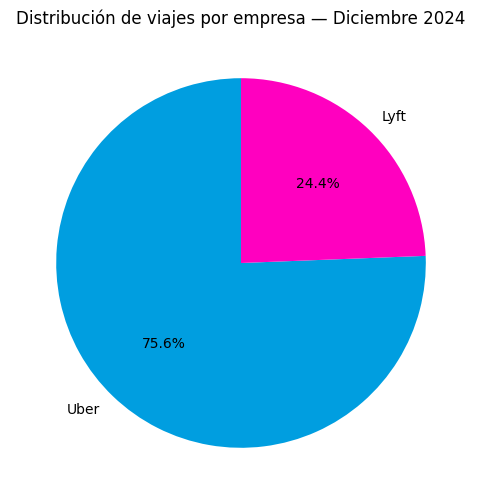

In [16]:
resultado = pd.DataFrame({
    'Empresa': ['Uber', 'Lyft'],
    'Viajes': conteo_licencia.values,
    'Porcentaje (%)': porcentaje_empresa.values
})

resultado


# Etiquetas con nombres reales
etiquetas = ['Uber', 'Lyft']
colores = ['#009EE0', '#FF00BF']

# Gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(
    conteo_licencia.values,
    labels=etiquetas,
    colors=colores,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribución de viajes por empresa — Diciembre 2024')
plt.show()

## ¿Cuáles son las zonas con mas demanda?

In [17]:
# Contamos viajes por zona de origen
viajes_por_zona = df.groupby('PULocationID').size().reset_index(name='total_viajes')

# Cruzamos con la tabla de zonas para obtener los nombres
viajes_por_zona = viajes_por_zona.merge(df_zonas, left_on='PULocationID', right_on='LocationID')

# Top 10 zonas con más viajes
top_zonas = viajes_por_zona.sort_values('total_viajes', ascending=False)[['Zone', 'Borough', 'total_viajes']].head(10)

top_zonas

,Zone,Borough,total_viajes
135,LaGuardia Airport,Queens,409221
129,JFK Airport,Queens,347938
60,Crown Heights North,Brooklyn,270234
78,East Village,Manhattan,261916
227,Times Sq/Theatre District,Manhattan,236776
67,East Chelsea,Manhattan,231837
75,East New York,Brooklyn,230774
158,Midtown Center,Manhattan,230043
228,TriBeCa/Civic Center,Manhattan,227748
231,Union Sq,Manhattan,219815


In [22]:
# Calculamos porcentaje dentro del top 10
top_zonas['porcentaje'] = (top_zonas['total_viajes'] / top_zonas['total_viajes'].sum() * 100).round(2)

top_zonas

,Zone,Borough,total_viajes,porcentaje
135,LaGuardia Airport,Queens,409221,15.35
129,JFK Airport,Queens,347938,13.05
60,Crown Heights North,Brooklyn,270234,10.14
78,East Village,Manhattan,261916,9.82
227,Times Sq/Theatre District,Manhattan,236776,8.88
67,East Chelsea,Manhattan,231837,8.70
75,East New York,Brooklyn,230774,8.66
158,Midtown Center,Manhattan,230043,8.63
228,TriBeCa/Civic Center,Manhattan,227748,8.54
231,Union Sq,Manhattan,219815,8.24


### Visualización de las zonas con mayores transacciones

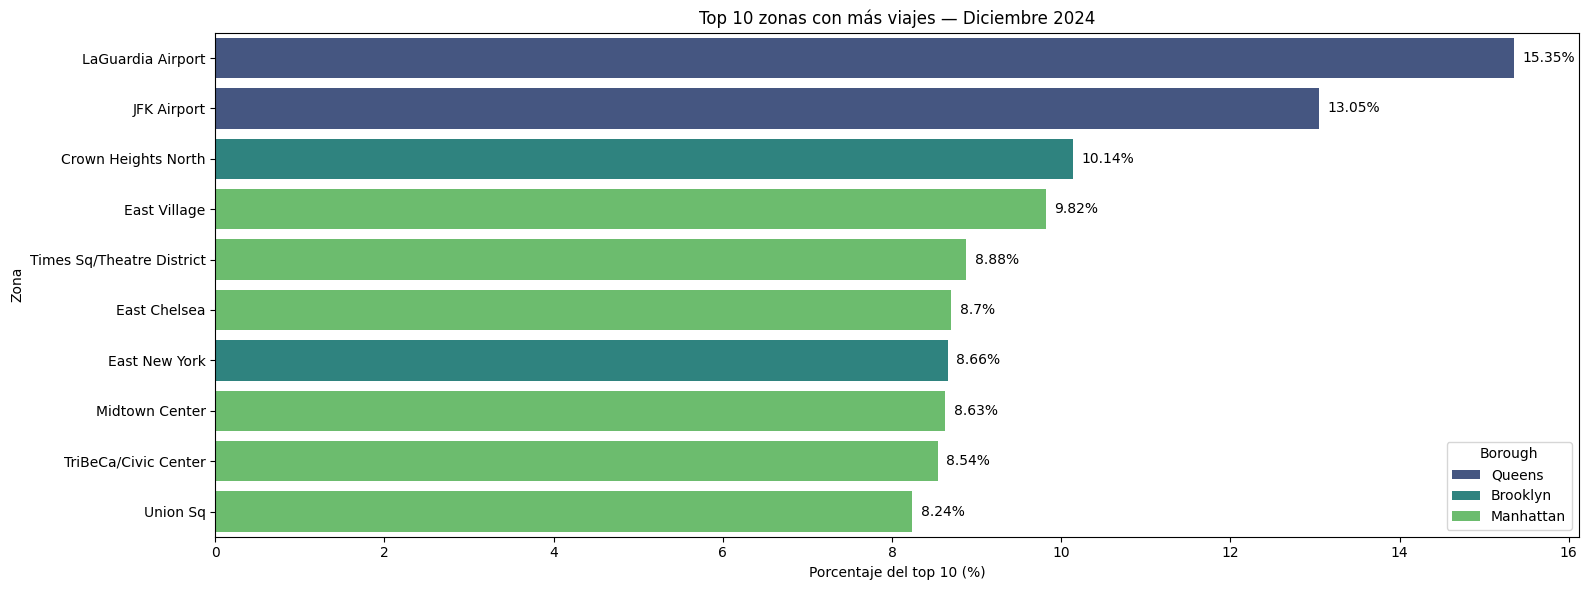

In [29]:
plt.figure(figsize=(16, 6))
sns.barplot(
    data=top_zonas,
    x='porcentaje',
    y='Zone',
    hue='Borough',
    palette='viridis'
)

# Agregamos etiquetas de porcentaje
for i, (_, row) in enumerate(top_zonas.iterrows()):
    plt.text(row['porcentaje'] + 0.1, i, f"{row['porcentaje']}%", va='center')

plt.title('Top 10 zonas con más viajes — Diciembre 2024')
plt.xlabel('Porcentaje del top 10 (%)')
plt.ylabel('Zona')
plt.tight_layout()
plt.show()

## ¿Cómo se dividen las transacciones entre los 5 Boroughs de NYC?
NYC está dividida en 5 Boroughs: Manhattan, Brooklyn, Queens, Bronx y Staten Island. 
¿Cuál tiene más demanda de viajes de Uber/Lyft en diciembre 2024?

In [30]:
# Agrupamos por Borough
viajes_por_borough = df.merge(df_zonas, left_on='PULocationID', right_on='LocationID') \
                       .groupby('Borough').size().reset_index(name='total_viajes')

# Calculamos porcentaje
viajes_por_borough['porcentaje'] = (viajes_por_borough['total_viajes'] / viajes_por_borough['total_viajes'].sum() * 100).round(2)

# Ordenamos de mayor a menor
viajes_por_borough = viajes_por_borough.sort_values('total_viajes', ascending=False)

viajes_por_borough

,Borough,total_viajes,porcentaje
3,Manhattan,7980907,37.88
1,Brooklyn,5570035,26.44
4,Queens,4532041,21.51
0,Bronx,2659646,12.62
5,Staten Island,325464,1.54
2,EWR,1,0.00


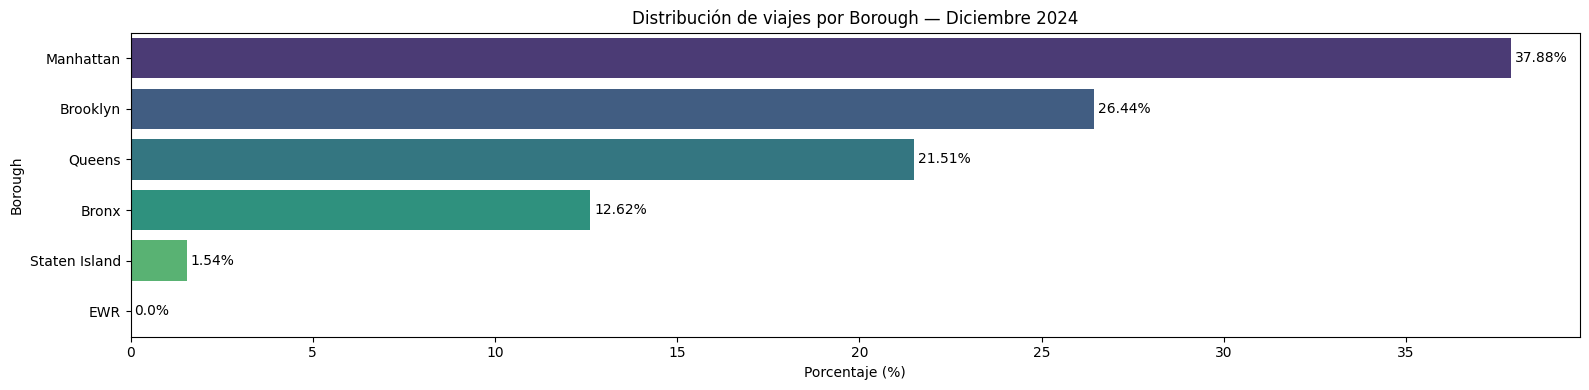

In [31]:
plt.figure(figsize=(16, 4))
sns.barplot(
    data=viajes_por_borough,
    x='porcentaje',
    y='Borough',
    hue='Borough',
    palette='viridis'
)

# Etiquetas de porcentaje
for i, (_, row) in enumerate(viajes_por_borough.iterrows()):
    plt.text(row['porcentaje'] + 0.1, i, f"{row['porcentaje']}%", va='center')

plt.title('Distribución de viajes por Borough — Diciembre 2024')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()

## ¿Cúales son las horas pico de cada Borough?

In [ ]:
# Extraemos la hora del pickup
df['hora'] = df['pickup_datetime'].dt.hour

In [35]:
# Cruzamos df con la tabla de zonas para obtener el Borough
df_con_borough = df.merge(df_zonas, left_on='PULocationID', right_on='LocationID')

# Filtramos EWR
df_con_borough = df_con_borough[df_con_borough['Borough'] != 'EWR']

# Extraemos la hora
df_con_borough['hora'] = df_con_borough['pickup_datetime'].dt.hour

# Agrupamos por Borough y hora
horas_pico = df_con_borough.groupby(['Borough', 'hora']).size().reset_index(name='total_viajes')

# Para cada Borough nos quedamos solo con la hora que tiene más viajes
horas_pico = horas_pico.loc[horas_pico.groupby('Borough')['total_viajes'].idxmax()]

horas_pico.sort_values('total_viajes', ascending=False)

,Borough,hora,total_viajes
68,Manhattan,20,507027
43,Brooklyn,19,341201
90,Queens,18,256737
8,Bronx,8,167142
113,Staten Island,17,20567


## Cúales son las horas pico de cada día?

In [37]:
# Extraemos hora y día de la semana
df_con_borough['dia_semana'] = df_con_borough['pickup_datetime'].dt.day_name()

In [39]:
# Agrupamos por Borough, día y hora
horas_pico_dia = df_con_borough.groupby(['Borough', 'dia_semana', 'hora']).size().reset_index(name='total_viajes')

# Para cada combinación de Borough y día nos quedamos con la hora pico
horas_pico_dia = horas_pico_dia.loc[horas_pico_dia.groupby(['Borough', 'dia_semana'])['total_viajes'].idxmax()]

# Ordenamos por día de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
horas_pico_dia['dia_semana'] = pd.Categorical(horas_pico_dia['dia_semana'], categories=orden_dias, ordered=True)

horas_pico_dia.sort_values(['Borough', 'dia_semana'])

,Borough,dia_semana,hora,total_viajes
32,Bronx,Monday,8,32114
128,Bronx,Tuesday,8,29614
152,Bronx,Wednesday,8,22970
104,Bronx,Thursday,8,26355
8,Bronx,Friday,8,27871
67,Bronx,Saturday,19,22022
89,Bronx,Sunday,17,20943
200,Brooklyn,Monday,8,47577
310,Brooklyn,Tuesday,22,55450
331,Brooklyn,Wednesday,19,45506


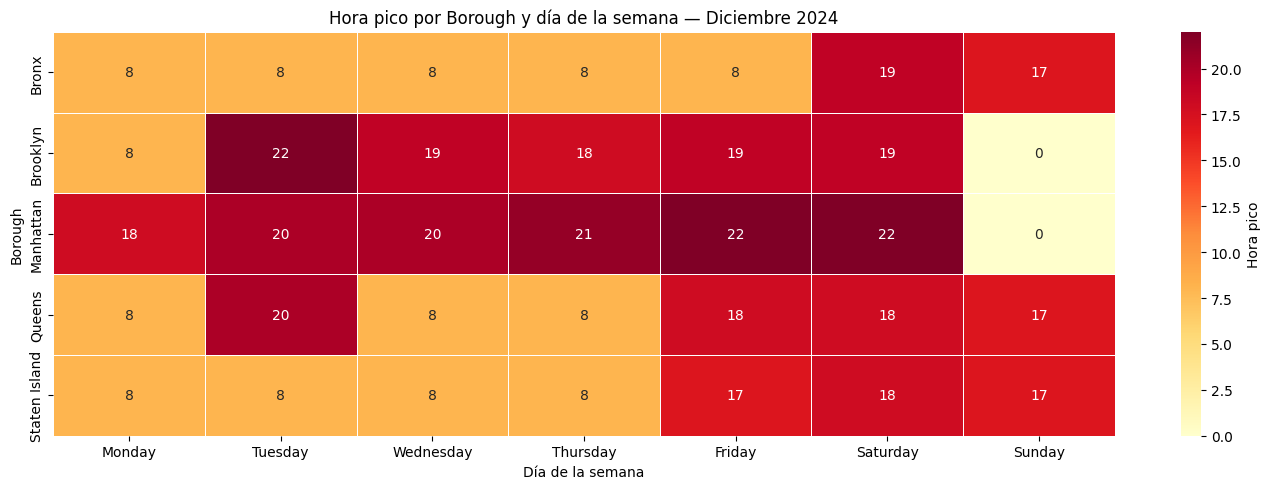

In [40]:
# Pivoteamos para el heatmap
pivot_horas = horas_pico_dia.pivot_table(
    index='Borough',
    columns='dia_semana',
    values='hora',
    aggfunc='first'
)[orden_dias]

# Graficamos
plt.figure(figsize=(14, 5))
sns.heatmap(
    pivot_horas,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Hora pico'}
)
plt.title('Hora pico por Borough y día de la semana — Diciembre 2024')
plt.xlabel('Día de la semana')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()

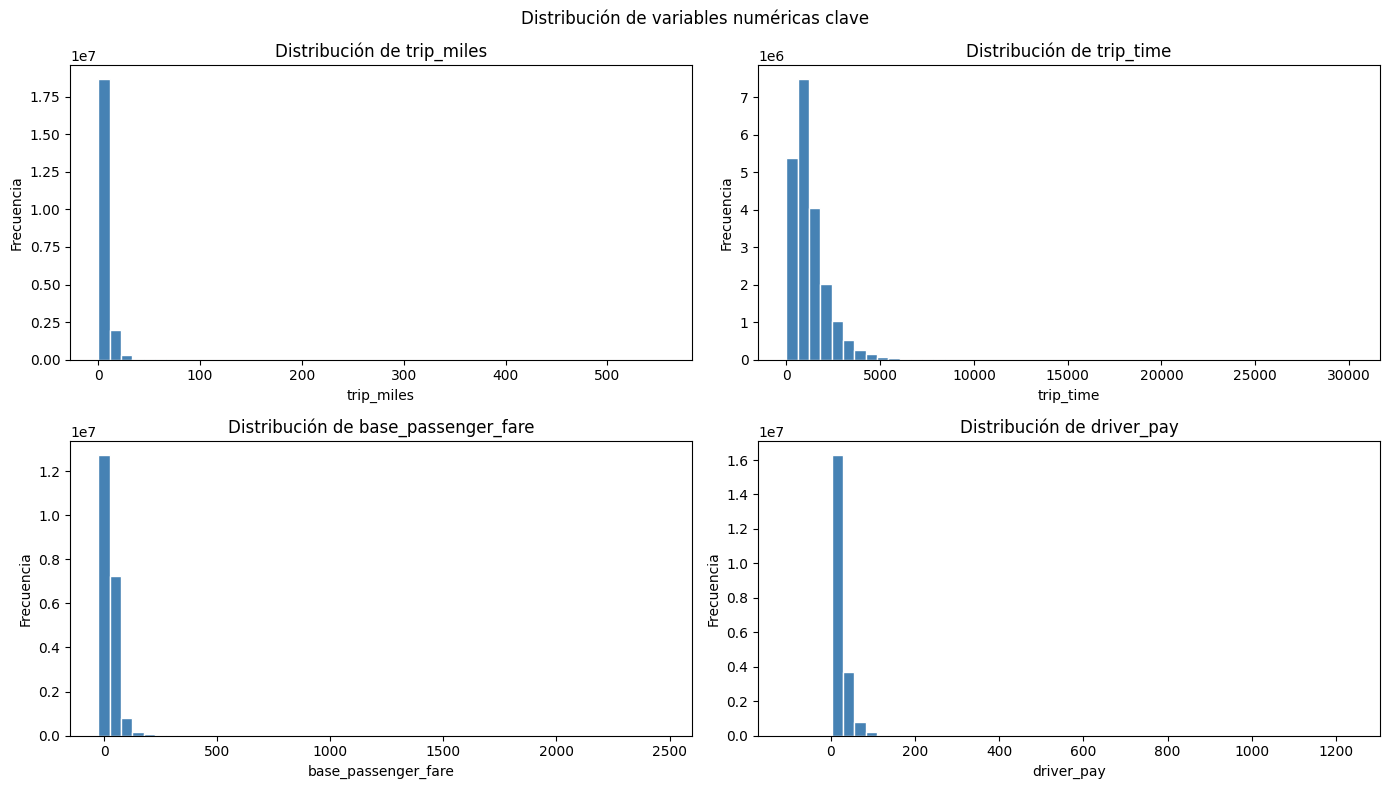

In [31]:
#Visualizacion de distribucion de las variables numericas

columnas_viz = ['trip_miles', 'trip_time', 'base_passenger_fare', 'driver_pay']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_viz):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas clave')
plt.tight_layout()
plt.show()


## Parte 2, Proyecto HVFHS terminación

### Primeramente tenemos que separar la data, es decir ¿que data usaremos para entrenamiento? y ¿que data sera para la data de prod?, a raiz de eso tenemos que separar nuesotro dataset.

In [7]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(df_train.shape,df_test.shape)

(16855080, 24) (4213771, 24)


In [21]:
#Estadistica descriptiva
df_train.describe()

,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay
count,16855080,12757647,16855080,16855080,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07,1.685508e+07
mean,2024-12-16 01:02:12.315996,2024-12-15 23:26:31.434484,2024-12-16 01:07:24.318701,2024-12-16 01:27:58.462361,1.382505e+02,1.417894e+02,5.102357e+00,1.234144e+03,2.792087e+01,1.226878e+00,7.738820e-01,2.294940e+00,9.935364e-01,2.140967e-01,1.285759e+00,2.153093e+01
min,2024-11-30 23:19:00,2024-11-30 22:22:04,2024-12-01 00:00:00,2024-12-01 00:01:33,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-2.559000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.053800e+02
25%,2024-12-08 11:47:21,2024-12-08 11:45:00,2024-12-08 11:52:10,2024-12-08 12:10:43,7.500000e+01,7.500000e+01,1.516000e+00,5.940000e+02,1.251000e+01,0.000000e+00,3.400000e-01,1.030000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.480000e+00
50%,2024-12-15 13:06:27,2024-12-15 10:05:51,2024-12-15 13:12:01,2024-12-15 13:32:40.500000,1.380000e+02,1.400000e+02,2.950000e+00,9.800000e+02,2.003000e+01,0.000000e+00,5.500000e-01,1.670000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.605000e+01
75%,2024-12-22 20:45:41,2024-12-22 18:17:17.500000,2024-12-22 20:50:20,2024-12-22 21:08:25,2.090000e+02,2.160000e+02,6.400000e+00,1.591000e+03,3.332000e+01,0.000000e+00,9.300000e-01,2.840000e+00,2.750000e+00,0.000000e+00,0.000000e+00,2.724000e+01
max,2025-01-01 00:10:00,2024-12-31 23:59:58,2024-12-31 23:59:59,2025-01-01 02:04:13,2.650000e+02,2.650000e+02,5.552500e+02,3.015000e+04,2.473360e+03,1.096100e+02,6.802000e+01,1.014700e+02,5.500000e+00,7.250000e+00,3.362100e+02,1.237600e+03
std,NaN,NaN,NaN,NaN,7.487754e+01,7.808824e+01,6.040960e+00,9.228831e+02,2.597826e+01,4.193690e+00,7.405980e-01,2.082692e+00,1.314930e+00,7.018561e-01,3.871362e+00,1.849000e+01


### Teniendo esta informacion debemos de revisar outliers, para determinar con la formula el IQR.

In [12]:
columnas_numericas = ['trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay']

#Dado que tenemos que sacar el outliers, vamos a usar el método del rango intercuartílico (IQR), usaremos un for loop

for coulumna in columnas_numericas:
    Q1 = df_train[coulumna].quantile(0.25)
    Q3 = df_train[coulumna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df_train[(df_train[coulumna] < limite_inferior) | (df_train[coulumna] > limite_superior)].shape[0]
    pct = round(outliers / len(df_train) * 100, 2)
    print(f'{coulumna:<25} | Limite inferior: {limite_inferior:10.2f} | Limite superior: {limite_superior:10.2f} | Outliers: {outliers} ({pct:.2f}%)')

trip_miles                | Limite inferior:      -5.81 | Limite superior:      13.73 | Outliers: 1302802 (7.73%)
trip_time                 | Limite inferior:    -901.50 | Limite superior:    3086.50 | Outliers: 798605 (4.74%)
base_passenger_fare       | Limite inferior:     -18.71 | Limite superior:      64.53 | Outliers: 1194070 (7.08%)
tolls                     | Limite inferior:       0.00 | Limite superior:       0.00 | Outliers: 2285982 (13.56%)
bcf                       | Limite inferior:      -0.55 | Limite superior:       1.82 | Outliers: 1215222 (7.21%)
sales_tax                 | Limite inferior:      -1.68 | Limite superior:       5.55 | Outliers: 1109202 (6.58%)
congestion_surcharge      | Limite inferior:      -4.12 | Limite superior:       6.88 | Outliers: 0 (0.00%)
airport_fee               | Limite inferior:       0.00 | Limite superior:       0.00 | Outliers: 1447243 (8.59%)
tips                      | Limite inferior:       0.00 | Limite superior:       0.00 | Outlie

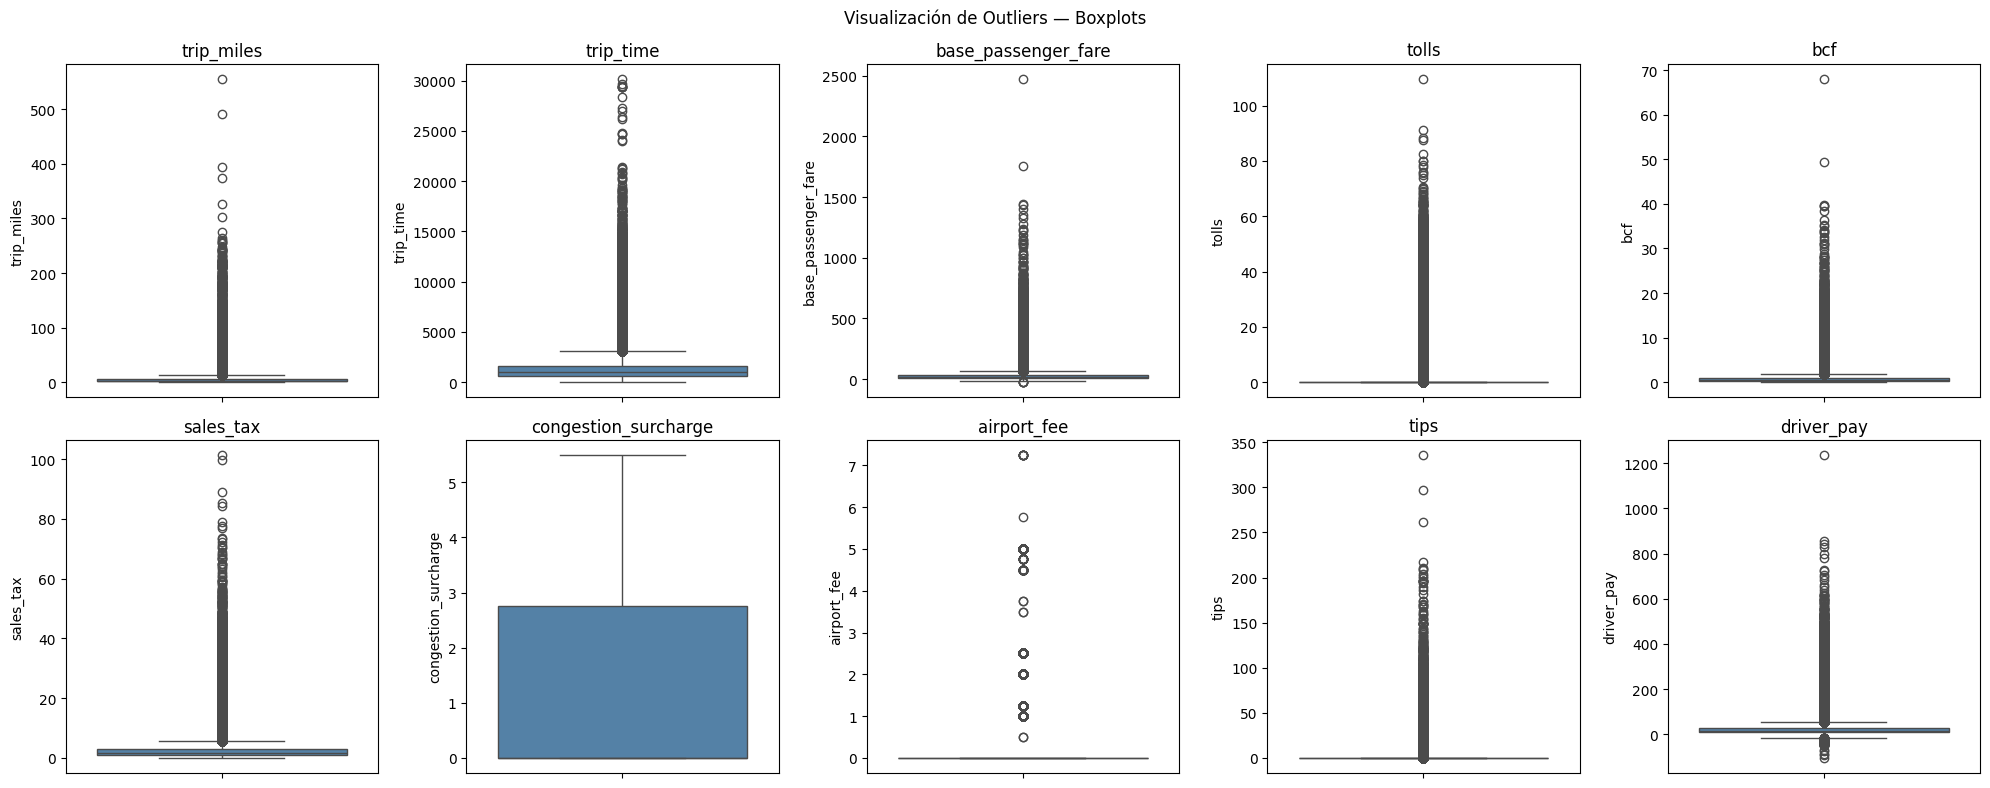

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=df_train[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Visualización de Outliers — Boxplots')
plt.tight_layout()
plt.show()

### Interpretación de Boxplots
Todas las variables numéricas muestran asimetría positiva con colas 
largas hacia valores altos. Esto confirma la necesidad de aplicar 
transformación logarítmica para comprimir los valores extremos reales.

In [13]:
#tratemos de hacer una limpieza con estas variables.
total_antes = len(df_train)
df_train_transformed = df_train.copy()
df_train_transformed = df_train_transformed[df_train_transformed['trip_miles'] > 0]
df_train_transformed = df_train_transformed[df_train_transformed['trip_time'] > 0]
df_train_transformed = df_train_transformed[df_train_transformed['base_passenger_fare'] > 0]
df_train_transformed = df_train_transformed[df_train_transformed['driver_pay'] > 0]

print( f'Registros antes de la limpieza: {total_antes:,}')
print(f'Registros después de la limpieza: {len(df_train_transformed):,}')
print(f'Eliminados: {total_antes - len(df_train_transformed):,}')

Registros antes de la limpieza: 16,855,080
Registros después de la limpieza: 16,821,032
Eliminados: 34,048


In [14]:
#Dado que sacar los outliers, viendo el termino de limpieza los valores eliminados no son altos, nos da la confianza de hacer logaritmica.
df_train_transformed['trip_miles_log'] = np.log(df_train_transformed['trip_miles'])
df_train_transformed['trip_time_log'] = np.log(df_train_transformed['trip_time'])
df_train_transformed['base_passenger_fare_log'] = np.log(df_train_transformed['base_passenger_fare'])
df_train_transformed['driver_pay_log'] = np.log(df_train_transformed['driver_pay'])
df_train_transformed[['trip_miles', 'trip_miles_log', 'driver_pay', 'driver_pay_log']].head()



,trip_miles,trip_miles_log,driver_pay,driver_pay_log
17523238,2.850,1.047319,9.14,2.212660
14720001,15.517,2.741936,43.17,3.765146
17722980,11.480,2.440606,30.04,3.402530
3676258,8.350,2.122262,47.86,3.868280
16672616,2.936,1.077048,16.90,2.827314


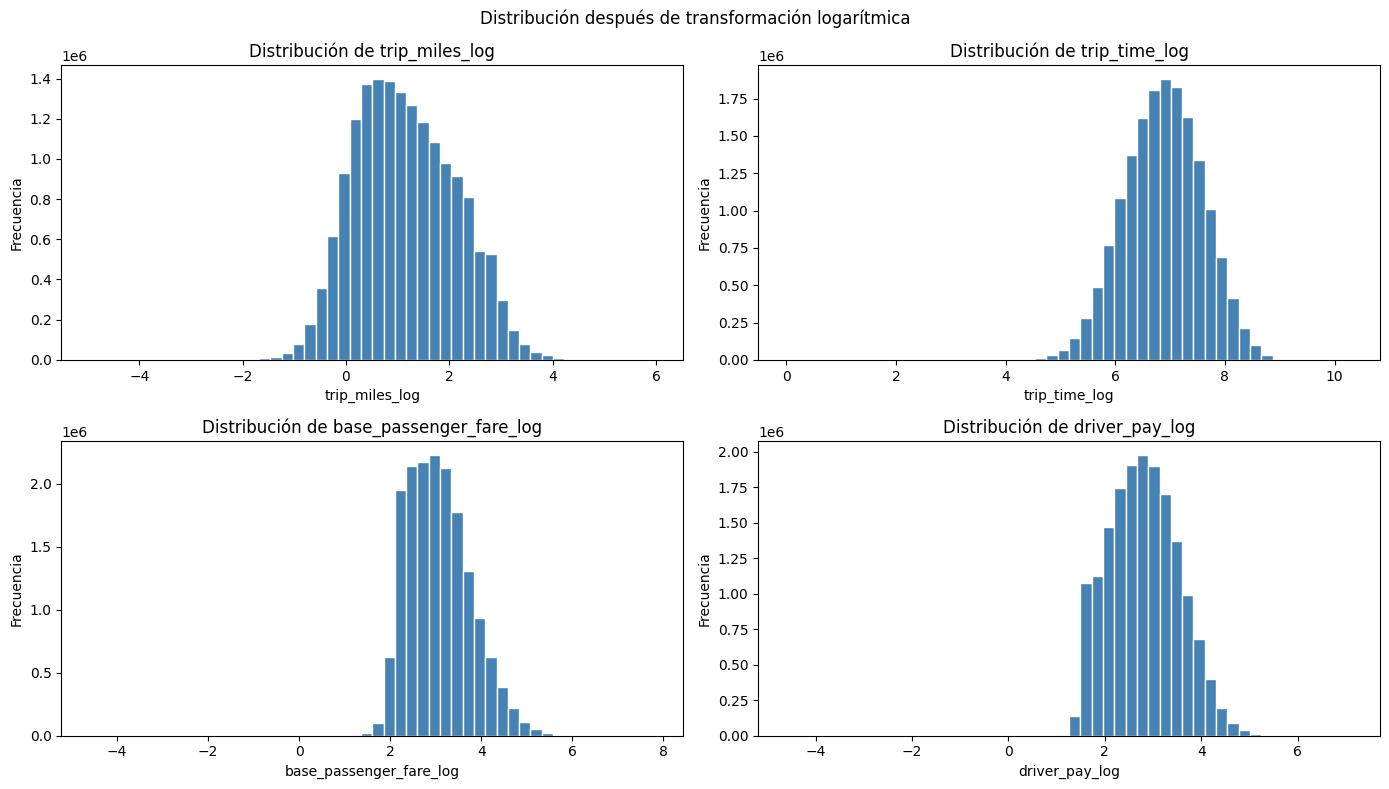

In [15]:
columnas_log = ['trip_miles_log', 'trip_time_log', 'base_passenger_fare_log', 'driver_pay_log']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_log):
    axes[i].hist(df_train_transformed[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución después de transformación logarítmica')
plt.tight_layout()
plt.show()

### Resultado de la transformación logarítmica
Las distribuciones originales tenían fuerte asimetría positiva.
Después de aplicar log() las distribuciones se aproximan a una 
distribución normal — forma de campana simétrica. Esto mejora 
significativamente el comportamiento para modelos de ML.


In [16]:
#Contemos nulos por columna

nulos = df_train_transformed.isnull().sum()
pct = (nulos / len(df_train_transformed) * 100).round(2)

resumen = pd.DataFrame({

    'Valores faltantes': nulos,
    'Porcentaje (%)': pct

}).sort_values('Valores faltantes', ascending=False)

resumen[resumen['Valores faltantes'] > 0]

,Valores faltantes,Porcentaje (%)
originating_base_num,4072138,24.21
on_scene_datetime,4072130,24.21


In [17]:
nulos_on_scene = df_train_transformed['on_scene_datetime'].isnull()
nulos_originated = df_train_transformed['originating_base_num'].isnull()

suma_nulos = (nulos_on_scene & nulos_originated).sum()
print(f'Número de registros con ambos campos nulos: {suma_nulos}') 


Número de registros con ambos campos nulos: 4072130


#### Dado que los valores nulos no nos favorecen a nuestro modelo, lo que haremos es eliminarlos como tal, de tal forma que eliminamos estas columnas con alto valores de nulos.

In [18]:
df_train_transformed = df_train_transformed.drop(columns=['on_scene_datetime', 'originating_base_num'])
print(f'Columnas restantes: {df_train_transformed.shape[1]}')
print(df_train_transformed.columns.to_list())

Columnas restantes: 26
['hvfhs_license_num', 'dispatching_base_num', 'request_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'trip_miles_log', 'trip_time_log', 'base_passenger_fare_log', 'driver_pay_log']


### Ahora, tratemos los valores faltantes.

In [12]:
df_train_transformed.isnull().sum()

hvfhs_license_num          0
dispatching_base_num       0
request_datetime           0
pickup_datetime            0
dropoff_datetime           0
PULocationID               0
DOLocationID               0
trip_miles                 0
trip_time                  0
base_passenger_fare        0
tolls                      0
bcf                        0
sales_tax                  0
congestion_surcharge       0
airport_fee                0
tips                       0
driver_pay                 0
shared_request_flag        0
shared_match_flag          0
access_a_ride_flag         0
wav_request_flag           0
wav_match_flag             0
trip_miles_log             0
trip_time_log              0
base_passenger_fare_log    0
driver_pay_log             0
dtype: int64

In [30]:
df_train_transformed.isna().sum()

hvfhs_license_num          0
dispatching_base_num       0
request_datetime           0
pickup_datetime            0
dropoff_datetime           0
PULocationID               0
DOLocationID               0
trip_miles                 0
trip_time                  0
base_passenger_fare        0
tolls                      0
bcf                        0
sales_tax                  0
congestion_surcharge       0
airport_fee                0
tips                       0
driver_pay                 0
shared_request_flag        0
shared_match_flag          0
access_a_ride_flag         0
wav_request_flag           0
wav_match_flag             0
trip_miles_log             0
trip_time_log              0
base_passenger_fare_log    0
driver_pay_log             0
dtype: int64

## Feature Engineering
En esta sección creamos nuevas variables a partir de las existentes 
para mejorar la capacidad predictiva del modelo.

### 1. Extracción de features desde fechas
A partir de pickup_datetime extraemos variables temporales útiles 
para predecir driver_pay — la hora, día de la semana y si es fin 
de semana son factores que afectan directamente la demanda y el pago.

In [19]:
df_train_transformed['hora'] = df_train_transformed['pickup_datetime'].dt.hour
df_train_transformed['dia_semana'] = df_train_transformed['pickup_datetime'].dt.dayofweek
df_train_transformed['es_fin_de_semana'] = df_train_transformed['dia_semana'].isin([5, 6]).astype(int)

df_train_transformed[['pickup_datetime', 'hora', 'dia_semana', 'es_fin_de_semana']].head()

,pickup_datetime,hora,dia_semana,es_fin_de_semana
17523238,2024-12-25 20:20:20,20,2,0
14720001,2024-12-21 13:59:07,13,5,1
17722980,2024-12-26 08:56:29,8,3,0
3676258,2024-12-06 14:47:50,14,4,0
16672616,2024-12-24 10:21:26,10,1,0


In [20]:
#Discretizamos la variable de hora en franjas horarias
df_train_transformed['franja_horaria'] = pd.cut(
    df_train_transformed['hora'],
    bins=[0, 6, 12, 18, 24],
    labels=[0, 1, 2, 3], #0: madrugada, 1: mañana, 2: tarde, 3: noche
    right=False
).astype(int)

In [21]:
#Encoding para la empresa.
df_train_transformed['es_uber'] = (df_train_transformed['hvfhs_license_num'] == 'HV0003').astype(int)

#Encoding de flags Y/N
flags = ['shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag']


for flag in flags:
    df_train_transformed[flag] = (df_train_transformed[flag] == 'Y').astype(int)

df_train_transformed[['es_uber'] + flags].head() 

,es_uber,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
17523238,1,1,1,0,0,0
14720001,0,0,0,0,0,0
17722980,1,0,0,0,0,0
3676258,1,0,0,0,0,0
16672616,0,0,0,0,0,0


In [22]:
### Ya teniendo todas las variables transformadas, podemos proceder a la fase de modelado.

features = ['trip_miles_log', 'trip_time_log', 'base_passenger_fare_log','tolls','bcf','sales_tax','congestion_surcharge','airport_fee','tips', 'hora', 'dia_semana', 'es_fin_de_semana','franja_horaria', 'es_uber', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag'] 

target = 'driver_pay_log'

print(f'Total features: {len(features)}')

Total features: 19


In [23]:
X_train = df_train_transformed[features]
Y_train = df_train_transformed[target]

print(X_train.shape, Y_train.shape)

(16821032, 19) (16821032,)


### Escalado y Normalización
Se aplica estandarización (Z-score) porque:
- El problema es de regresión
- Las distribuciones después del log son aproximadamente normales
- La fórmula es: X_estandarizado = (X - media) / desviación estándar

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)

print(X_train_scaled.mean(), X_train_scaled.std())

trip_miles_log            -8.937589e-17
trip_time_log              4.568281e-16
base_passenger_fare_log    7.780109e-16
tolls                     -5.390669e-17
bcf                       -5.993538e-17
sales_tax                  8.353645e-18
congestion_surcharge      -9.367437e-18
airport_fee               -7.458805e-17
tips                      -6.424737e-17
hora                       7.064102e-17
dia_semana                 2.206011e-17
es_fin_de_semana          -6.299027e-17
franja_horaria            -2.919721e-17
es_uber                    1.397140e-16
shared_request_flag        4.728325e-17
shared_match_flag         -4.525567e-17
access_a_ride_flag        -1.297654e-17
wav_request_flag          -3.011638e-17
wav_match_flag             2.765624e-17
dtype: float64 trip_miles_log             1.0
trip_time_log              1.0
base_passenger_fare_log    1.0
tolls                      1.0
bcf                        1.0
sales_tax                  1.0
congestion_surcharge       1.0
airport_

## Selección de Features — Comparación de métodos de filtrado

Aplicamos tres métodos de filtrado para evaluar la relación de cada 
feature con el target driver_pay_log:

- **Pearson** — mide correlación lineal. Sensible a outliers.
- **Spearman** — mide relación monótona. Más robusto que Pearson ante outliers.
- **Información Mutua** — no asume ninguna distribución. Captura relaciones no lineales.

Según lo visto en clase, no alcanza con un solo método —
cada uno tiene sus fortalezas y debilidades. Comparamos los tres 
para seleccionar las features más consistentemente importantes. En este escenario por el tratado que se tiene con los 0s se ha elegido spearman.

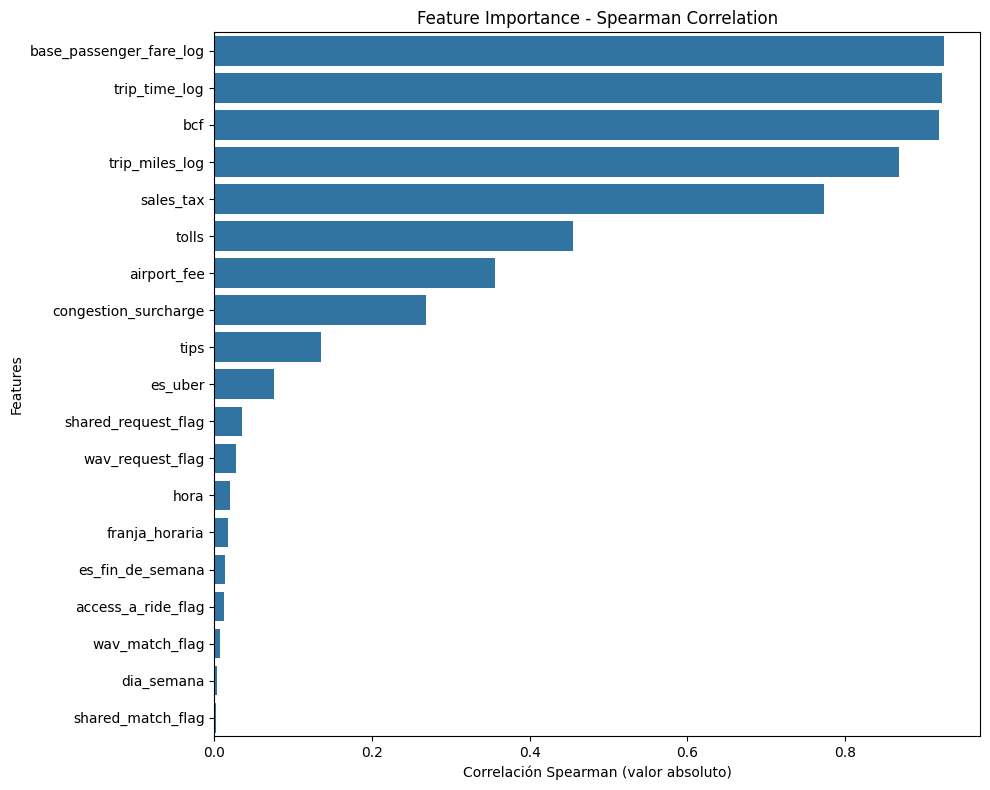

In [26]:
#Spearman
corr_spearman = X_train_scaled.join(Y_train).corr(method='spearman')[target].drop(target).abs()
corr_spearman_sorted = corr_spearman.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=corr_spearman_sorted.reset_index(), 
            x='driver_pay_log',  # Renombramos la columna de correlación
            y='index')            # Las features
plt.xlabel('Correlación Spearman (valor absoluto)')
plt.ylabel('Features')
plt.title('Feature Importance - Spearman Correlation')
plt.tight_layout()
plt.show()

In [30]:
#Seleccionar features para el threshold

threshold = 0.3
features_seleccionadas = corr_spearman_sorted[corr_spearman_sorted > threshold].index.tolist()
print(f'Features seleccionadas (Spearman > {threshold}):')
print(f'Total: {len(features_seleccionadas)}\n')

for feature in features_seleccionadas:
    print(f'{feature}: {corr_spearman[feature]:.4f}')

Features seleccionadas (Spearman > 0.3):
Total: 7

base_passenger_fare_log: 0.9250
trip_time_log: 0.9231
bcf: 0.9196
trip_miles_log: 0.8683
sales_tax: 0.7733
tolls: 0.4544
airport_fee: 0.3557


## Test Set

Preparamos el conjunto de prueba aplicando las mismas transformaciones realizadas en train.
Luego entrenaremos el modelo y realizaremos las evaluaciones de performance.

In [33]:
#Cargar el dataset de test para aplicar las mismas transformaciones y evaluar el modelo.

df_test_transformed = df_test.copy()

df_test_transformed = df_test_transformed[df_test_transformed['trip_miles'] > 0]
df_test_transformed = df_test_transformed[df_test_transformed['trip_time'] > 0]
df_test_transformed = df_test_transformed[df_test_transformed['base_passenger_fare'] > 0]
df_test_transformed = df_test_transformed[df_test_transformed['driver_pay'] > 0]

print(f'Registros en test después de limpieza: {df_test_transformed.shape}')

#transformación logarítmica

df_test_transformed['trip_miles_log'] = np.log(df_test_transformed['trip_miles'])
df_test_transformed['trip_time_log'] = np.log(df_test_transformed['trip_time'])
df_test_transformed['base_passenger_fare_log'] = np.log(df_test_transformed['base_passenger_fare'])
df_test_transformed['driver_pay_log'] = np.log(df_test_transformed['driver_pay'])  

#Eliminar columnas con muchos nulos
df_test_transformed = df_test_transformed.drop(columns=['on_scene_datetime', 'originating_base_num'])


#Feature engineering como en train
df_test_transformed['hora'] = df_test_transformed['pickup_datetime'].dt.hour
df_test_transformed['dia_semana'] = df_test_transformed['pickup_datetime'].dt.dayofweek
df_test_transformed['es_fin_de_semana'] = df_test_transformed['dia_semana'].isin([5, 6]).astype(int)

#Discretizamos la variable de hora en franjas horarias
df_test_transformed['franja_horaria'] = pd.cut(
    df_test_transformed['hora'],
    bins=[0, 6, 12, 18, 24],
    labels=[0, 1, 2, 3], #0: madrugada, 1: mañana, 2: tarde, 3: noche
    right=False
).astype(int)

df_test_transformed['es_uber'] = (df_test_transformed['hvfhs_license_num'] == 'HV0003').astype(int)

#Encoding de flags Y/N
flags = ['shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag']
for flag in flags:
    df_test_transformed[flag] = (df_test_transformed[flag] == 'Y').astype(int)


#Seleccionar las feautures originales antes de spearman para luego aplicar el modelo

features = ['trip_miles_log', 'trip_time_log', 'base_passenger_fare_log','tolls','bcf','sales_tax',
            'congestion_surcharge','airport_fee','tips', 'hora', 'dia_semana', 'es_fin_de_semana',
            'franja_horaria', 'es_uber', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag']

target = 'driver_pay_log'

X_test = df_test_transformed[features]
Y_test = df_test_transformed[target]

print(f'Test con 18 feautures: {X_test.shape}')

#Escalar con el mismo scaler que el train
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

#Las 7 variables con mayor correlación según Spearman
features_seleccionadas = ['base_passenger_fare_log', 'trip_time_log', 'bcf', 
                          'trip_miles_log', 'sales_tax', 'tolls', 'airport_fee']

X_test_final = X_test_scaled[features_seleccionadas]
Y_test_final = Y_test

print(f'Test con features seleccionadas: {X_test_final.shape}')
print(f'Features finales: {X_test_final.columns.tolist()}')


Registros en test después de limpieza: (4205223, 24)
Test con 18 feautures: (4205223, 19)
Test con features seleccionadas: (4205223, 7)
Features finales: ['base_passenger_fare_log', 'trip_time_log', 'bcf', 'trip_miles_log', 'sales_tax', 'tolls', 'airport_fee']


In [34]:
#Realicemos pruebas

# Validación rápida del pipeline

print("TRAIN SET")
print(f"Shape: {df_train_transformed.shape}")
print(f"Features seleccionadas: {len(features_seleccionadas)}")
print(features_seleccionadas)

print("\nTEST SET")
print(f"Shape: {df_test_transformed.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

print("\nNulos")
print(f"Train: {X_train_scaled.isnull().sum().sum()}")
print(f"Test: {X_test_final.isnull().sum().sum()}")

print("\nEscalado (train)")
print(f"Media: {X_train_scaled.mean().mean():.6f}")
print(f"Std: {X_train_scaled.std().mean():.6f}")

print("\nTarget")
print(f"Train - media: {Y_train.mean():.4f}, std: {Y_train.std():.4f}")
print(f"Test - media: {Y_test_final.mean():.4f}, std: {Y_test_final.std():.4f}")

TRAIN SET
Shape: (16821032, 31)
Features seleccionadas: 7
['base_passenger_fare_log', 'trip_time_log', 'bcf', 'trip_miles_log', 'sales_tax', 'tolls', 'airport_fee']

TEST SET
Shape: (4205223, 31)
X_test_final shape: (4205223, 7)

Nulos
Train: 0
Test: 0

Escalado (train)
Media: 0.000000
Std: 1.000000

Target
Train - media: 2.7998, std: 0.7206
Test - media: 2.8000, std: 0.7209


In [36]:
#Entrenar Ridge 
X_train_final = X_train_scaled[features_seleccionadas]
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_final, Y_train)

#Predicciones
Y_train_pred = ridge.predict(X_train_final)
Y_test_pred = ridge.predict(X_test_final)

#Metricas en train
r2_train = r2_score(Y_train, Y_train_pred)
rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
mae_train = mean_absolute_error(Y_train, Y_train_pred)

#Metricas en test
r2_test = r2_score(Y_test_final, Y_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y_test_final, Y_test_pred))
mae_test = mean_absolute_error(Y_test_final, Y_test_pred)


print("\nResultados - Ridge Regression:")
print("=" * 50)
print("\nTRAIN:")
print(f"R²: {r2_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAE: {mae_train:.4f}")

print("\nTEST:")
print(f"R²: {r2_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")

# Coeficientes
print("\nCOEFICIENTES:")
coef_df = pd.DataFrame({
    'Feature': features_seleccionadas,
    'Coeficiente': ridge.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(coef_df)



Resultados - Ridge Regression:

TRAIN:
R²: 0.9221
RMSE: 0.2012
MAE: 0.1470

TEST:
R²: 0.9221
RMSE: 0.2013
MAE: 0.1470

COEFICIENTES:
                   Feature  Coeficiente
0  base_passenger_fare_log     0.324129
1            trip_time_log     0.260950
3           trip_miles_log     0.125470
5                    tolls     0.017195
4                sales_tax     0.014528
6              airport_fee    -0.013819
2                      bcf     0.007706


## Conclusiones y Justificación del Análisis

### Problema planteado
Predecir el **driver_pay_log** (pago del conductor) a partir de características del viaje en el dataset HVFHS 2024.
Se trata de un problema de **regresión supervisada**.

**Justificación de la elección del target:**

El dataset HVFHS contiene múltiples variables relacionadas a viajes (distancia, tiempo, tarifa, propinas, etc.) 
y diferentes métricas de pago (base_passenger_fare, tolls, airport_fee, tips, driver_pay, etc.).

Se eligió **driver_pay** como target porque:
1. **Es la variable de mayor interés comercial** — Predecir lo que gana un conductor permite optimizar asignación de viajes
2. **Tiene relación causal con otras variables** — El pago depende de características del viaje (distancia, tiempo, tarifa)
3. **Tiene variabilidad suficiente** — No es constante, permite entrenar un modelo discriminativo
4. **Es predecible** — La mayoría de features tienen correlación con driver_pay, indicando relación genuina

Se aplicó transformación logarítmica a driver_pay porque:
- La distribución original era asimétricamente positiva (muchos viajes cortos/baratos, pocos muy lucrativos)
- Log normaliza la distribución y estabiliza la varianza
- Convierte relaciones multiplicativas en aditivas, mejorando la linealidad

Se trata de un problema de **regresión supervisada** — predecir un valor continuo.


### Pipeline de preparación de datos

#### 1. Limpieza básica
Se eliminaron registros donde `trip_miles`, `trip_time`, `base_passenger_fare` y `driver_pay` eran <= 0.
**Justificación:** Valores negativos o cero no tienen sentido en este contexto y serían errores de medición.

#### 2. Transformación logarítmica
Se aplicó log natural a: `trip_miles`, `trip_time`, `base_passenger_fare`, `driver_pay`.
**Justificación:** Las distribuciones originales eran asimétricas positivas con colas largas. 
La transformación log normalizó estas distribuciones y estabilizó la varianza, mejorando la relación lineal con el target.

#### 3. Feature engineering
Se crearon:
- **hora** y **dia_semana** — patrones temporales afectan demanda y precios
- **es_fin_de_semana** — comportamiento diferente entre semana y fin de semana
- **franja_horaria** — discretización de hora en 4 rangos (madrugada, mañana, tarde, noche)
- **es_uber** — dummy para diferenciar proveedores
- **flags Y/N** — conversión de flags a binarios (shared_request, access_a_ride, etc.)

**Justificación:** El pago del conductor depende del contexto temporal y tipo de servicio, 
no solo de características del viaje. Estas variables capturan esos patrones.

#### 4. Selección de features con Spearman

Se calculó correlación de Spearman entre cada feature y el target.
Se seleccionaron 7 features con correlación > 0.3:
- `base_passenger_fare_log` (0.9250)
- `trip_time_log` (0.9231)
- `bcf` (0.9196)
- `trip_miles_log` (0.8683)
- `sales_tax` (0.7733)
- `tolls` (0.4544)
- `airport_fee` (0.3557)

**Justificación de Spearman:**

El dataset original contenía muchos **valores de 0** en features como tolls, airport_fee, congestion_surcharge, tips. 
Estos ceros no son valores faltantes sino características legítimas del viaje (no todos los viajes tienen peaje o tarifa de aeropuerto).

- **Pearson:** Sería sensible a estos 0s y a outliers, distorsionando las correlaciones
- **Spearman:** Mide relaciones **monótonas** basadas en **rangos**, no valores absolutos. 
  Los ceros no lo afectan tanto porque Spearman solo se importa del orden relativo de los datos, no de su magnitud
- **Información Mutua:** Hubiera sido overkill computacionalmente sin aportar más claridad

Por esto, **Spearman fue la mejor opción** para este dataset con presencia de ceros y distribuciones transformadas logarítmicamente.

El threshold 0.3 elimina ruido sin perder features relevantes.
Las correlaciones altas indican relaciones genuinas con el target.

#### 5. Escalado
Se aplicó StandardScaler (Z-score) al conjunto de train.
El mismo scaler se aplicó a test usando `.transform()` (sin refit).

**Justificación:**
- Ridge Regression requiere features en la misma escala para estabilidad
- Usar el scaler de train en test evita data leakage

### Modelo: Ridge Regression

Se eligió Ridge (regularización L2) sobre alternativas:
- **Linear Regression vanilla** → Multicolinealidad entre features (correlaciones 0.92+)
- **Ridge** → Penaliza coeficientes, controla multicolinealidad ✓
- **Lasso** → Innecesario, ya hicimos selección de features
- **Random Forest** → Overkill, features ya son limpias y lineales

### Resultados

TRAIN: R² = 0.9221, RMSE = 0.2012, MAE = 0.1470
TEST:  R² = 0.9221, RMSE = 0.2013, MAE = 0.1470

**Interpretación:**
- El modelo explica 92.21% de la varianza en driver_pay
- Train y test **idénticos** → sin overfitting
- Error promedio en log scale: 0.20 (muy bajo)

### Importancia de features (coeficientes)

1. **base_passenger_fare_log** (0.324) → Factor principal del pago
2. **trip_time_log** (0.261) → Tiempo de viaje muy relevante
3. **trip_miles_log** (0.125) → Distancia aporta
4. **tolls, sales_tax, airport_fee** (< 0.02) → Ajustes menores

**Conclusión:** El pago del conductor es principalmente función de la tarifa base y el tiempo de viaje.
El feature engineering capturó correctamente los patrones de demanda temporal.
La selección con Spearman, robusta ante la presencia de ceros en el dataset, 
eliminó ruido sin perder poder predictivo.